# Used Car Price Category Classification

## Problem Statement

This part of the project focuses on classifying used cars into price categories based on their characteristics.

Instead of predicting the exact vehicle price, the goal is to predict a price segment such as Budget, Mid-range, Premium, or Luxury.

This is a supervised multiclass classification problem.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [67]:
df = pd.read_csv("/kaggle/input/datasets/fatimakashif12/used-car-price-dataset/used_cars-selected-columns.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999"


In [68]:
print(df["price"].head())

0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
Name: price, dtype: object


In [69]:
print(df.columns)

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'price'],
      dtype='object')


In [71]:
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)

df.rename(columns={"milage": "mileage"}, inplace=True)

KeyError: 'milage'

In [72]:
print(df.columns)

Index(['brand', 'model', 'model_year', 'mileage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'price'],
      dtype='object')


In [73]:
df["fuel_type"] = df["fuel_type"].replace(
    ["–", "not supported"],
    "Unknown"
)

df["fuel_type"] = df["fuel_type"].fillna("Unknown")
df["accident"] = df["accident"].fillna("Unknown")

In [74]:
df["horsepower"] = df["engine"].str.extract(
    r'(\d+\.?\d*)HP'
)[0]

df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

df["horsepower"] = df["horsepower"].fillna(
    df["horsepower"].median()
)

In [75]:
df["engine_size"] = df["engine"].str.extract(
    r'(\d+\.?\d*)\s*(?:L|Liter)',
    expand=False
)

df["engine_size"] = pd.to_numeric(
    df["engine_size"],
    errors="coerce"
)

df["engine_size"] = df["engine_size"].fillna(
    df["engine_size"].median()
)

In [76]:
reference_year = df["model_year"].max()

df["car_age"] = reference_year - df["model_year"]

In [77]:
df = df.drop(index=693)
df.reset_index(drop=True, inplace=True)

In [78]:
df[
    [
        "brand",
        "mileage",
        "horsepower",
        "engine_size",
        "car_age",
        "price"
    ]
].head()

,brand,mileage,horsepower,engine_size,car_age,price
0,Ford,51000.0,300.0,3.7,11,"$10,300"
1,Hyundai,34742.0,310.0,3.8,3,"$38,005"
2,Lexus,22372.0,310.0,3.5,2,"$54,598"
3,INFINITI,88900.0,354.0,3.5,9,"$15,500"
4,Audi,9835.0,310.0,2.0,3,"$34,999"


## Creating the Classification Target

For the classification task, the exact vehicle price is converted into broader price categories.

The target classes are:

- Budget
- Mid-range
- Premium
- Luxury

This is done using binning with fixed price ranges, converting the continuous price variable into a multiclass classification target.

In [93]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

In [94]:
df["price_category"] = pd.cut(
    df["price"],
    bins=[0, 30000, 60000, 100000, float("inf")],
    labels=[
        "Budget",
        "Mid-range",
        "Premium",
        "Luxury"
    ]
)

In [95]:
df[
    [
        "brand",
        "price",
        "price_category"
    ]
].head(10)

,brand,price,price_category
0,Ford,10300,Budget
1,Hyundai,38005,Mid-range
2,Lexus,54598,Mid-range
3,INFINITI,15500,Budget
4,Audi,34999,Mid-range
5,Acura,14798,Budget
6,Audi,31000,Mid-range
7,BMW,7300,Budget
8,Lexus,41927,Mid-range
9,Tesla,69950,Premium


In [96]:
df["price_category"].value_counts()

price_category
Budget       1960
Mid-range    1336
Premium       479
Luxury        233
Name: count, dtype: int64

In [97]:
df["price_category"].value_counts(normalize=True) * 100

price_category
Budget       48.902196
Mid-range    33.333333
Premium      11.951098
Luxury        5.813373
Name: proportion, dtype: float64

## Class Distribution Analysis

The target classes are imbalanced.

Budget and Mid-range vehicles represent most of the dataset, while Premium and Luxury vehicles occur less frequently.

Because of this imbalance, accuracy alone may not provide a complete picture of model performance. Precision, recall, F1-score, and class-level performance will also be considered.

In [98]:
X = df[
    [
        "brand",
        "mileage",
        "fuel_type",
        "transmission",
        "accident",
        "horsepower",
        "engine_size",
        "car_age"
    ]
]

y = df["price_category"]

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (3206, 8)
Testing shape: (802, 8)

Training class distribution:
price_category
Budget       0.489083
Mid-range    0.333437
Premium      0.119464
Luxury       0.058016
Name: proportion, dtype: float64

Testing class distribution:
price_category
Budget       0.488778
Mid-range    0.332918
Premium      0.119701
Luxury       0.058603
Name: proportion, dtype: float64


## Preprocessing for Classification

The dataset contains both categorical and numerical features.

Categorical features are converted into numerical form using One-Hot Encoding.

Numerical features are passed through unchanged.

A ColumnTransformer is used to apply the appropriate preprocessing to each type of feature.

In [102]:
categorical_features = [
    "brand",
    "fuel_type",
    "transmission",
    "accident"
]

numerical_features = [
    "mileage",
    "horsepower",
    "engine_size",
    "car_age"
]

In [103]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Baseline Model: Dummy Classifier

Before training actual classification models, a Dummy Classifier is used as a baseline.

The `most_frequent` strategy always predicts the most common target class.

This provides a simple reference point that the real machine learning classifiers should outperform.

In [104]:
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

In [105]:
dummy_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission',
                                                   'accident'])])),
                ('model', DummyClassifier(strategy='most_frequent'))])

In [107]:
dummy_predictions = dummy_model.predict(
    X_test
)

In [108]:
dummy_accuracy = accuracy_score(
    y_test,
    dummy_predictions
)

dummy_precision = precision_score(
    y_test,
    dummy_predictions,
    average="weighted",
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    dummy_predictions,
    average="weighted",
    zero_division=0
)

dummy_f1 = f1_score(
    y_test,
    dummy_predictions,
    average="weighted",
    zero_division=0
)

print("Dummy Accuracy:", dummy_accuracy)
print("Dummy Precision:", dummy_precision)
print("Dummy Recall:", dummy_recall)
print("Dummy F1:", dummy_f1)

Dummy Accuracy: 0.48877805486284287
Dummy Precision: 0.23890398691550424
Dummy Recall: 0.48877805486284287
Dummy F1: 0.3209396943153005


In [109]:
print(
    classification_report(
        y_test,
        dummy_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Budget       0.49      1.00      0.66       392
      Luxury       0.00      0.00      0.00        47
   Mid-range       0.00      0.00      0.00       267
     Premium       0.00      0.00      0.00        96

    accuracy                           0.49       802
   macro avg       0.12      0.25      0.16       802
weighted avg       0.24      0.49      0.32       802



### Baseline Model Result

The Dummy Classifier achieved an accuracy of approximately 49%.

However, this does not indicate good classification performance.

Because the `most_frequent` strategy was used, the model predicted the majority class, Budget, for every observation.

As a result, Budget recall was 1.00, while Luxury, Mid-range, and Premium recall were 0.00.

This demonstrates why accuracy alone can be misleading when the target classes are imbalanced.

The actual machine learning classifiers should outperform this baseline while also identifying the minority classes.

## Logistic Regression Classifier

Logistic Regression is the first real classification model used in this project.

Because numerical features such as mileage, horsepower, engine size, and car age are on very different scales, StandardScaler will be applied to the numerical features before training.

The model will then be evaluated using accuracy, precision, recall, F1-score, and a classification report.

In [110]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [111]:
preprocessor_logistic = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [112]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logistic),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [113]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission',
                                                   'accident']),
                                                 ('numerical', StandardScaler(),
                                                  ['mileage', 'horsepower',
                                                   'engine_size',
                                                   'car_age'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [115]:
logistic_predictions = logistic_model.predict(
    X_test
)

In [117]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Accuracy:", logistic_accuracy)
print("Logistic Precision:", logistic_precision)
print("Logistic Recall:", logistic_recall)
print("Logistic F1:", logistic_f1)

Logistic Accuracy: 0.8017456359102244
Logistic Precision: 0.7978597672498603
Logistic Recall: 0.8017456359102244
Logistic F1: 0.798017479887091


In [118]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Budget       0.89      0.91      0.90       392
      Luxury       0.72      0.55      0.63        47
   Mid-range       0.73      0.78      0.75       267
     Premium       0.64      0.52      0.57        96

    accuracy                           0.80       802
   macro avg       0.75      0.69      0.71       802
weighted avg       0.80      0.80      0.80       802



### Logistic Regression Result

Logistic Regression achieved an overall accuracy of approximately 80%, which is a substantial improvement over the Dummy Classifier baseline.

The model performed best on the Budget class, with an F1-score of approximately 0.90, followed by Mid-range with an F1-score of approximately 0.75.

Performance was weaker for the Premium and Luxury classes, which have fewer training examples.

The weighted F1-score was approximately 0.80, while the macro F1-score was approximately 0.71.

This indicates that Logistic Regression learned meaningful relationships between the vehicle features and price categories, although minority-class performance can still be improved.

## Decision Tree Classifier

A Decision Tree Classifier is used as the next model.

Unlike Logistic Regression, a Decision Tree can learn nonlinear relationships and more complex decision boundaries between vehicle features and price categories.

The model will be evaluated using accuracy, precision, recall, F1-score, and a classification report.

In [120]:
from sklearn.tree import DecisionTreeClassifier

In [122]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [123]:
decision_tree_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission',
                                                   'accident'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [124]:
tree_predictions = decision_tree_model.predict(
    X_test
)

In [126]:
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Precision:", tree_precision)
print("Decision Tree Recall:", tree_recall)
print("Decision Tree F1:", tree_f1)

Decision Tree Accuracy: 0.7680798004987531
Decision Tree Precision: 0.7681839714395631
Decision Tree Recall: 0.7680798004987531
Decision Tree F1: 0.7679460811472957


In [127]:
print(
    classification_report(
        y_test,
        tree_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Budget       0.87      0.88      0.88       392
      Luxury       0.62      0.70      0.66        47
   Mid-range       0.72      0.70      0.71       267
     Premium       0.56      0.55      0.55        96

    accuracy                           0.77       802
   macro avg       0.69      0.71      0.70       802
weighted avg       0.77      0.77      0.77       802



### Decision Tree Result

The Decision Tree Classifier achieved an overall accuracy of approximately 77%.

Its weighted F1-score was approximately 0.77 and its macro F1-score was approximately 0.70.

Compared with Logistic Regression, the Decision Tree had slightly lower overall performance. However, it achieved better recall for the Luxury class, identifying approximately 70% of the actual Luxury vehicles.

This shows that different classifiers can perform differently across individual classes, even when one model has better overall metrics.

## Random Forest Classifier

Random Forest combines predictions from multiple decision trees instead of relying on a single tree.

This can reduce overfitting and improve generalization compared with an individual Decision Tree.

The model will be evaluated using the same classification metrics for fair comparison.

In [128]:
from sklearn.ensemble import RandomForestClassifier

In [130]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [131]:
random_forest_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission',
                                                   'accident'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [132]:
rf_predictions = random_forest_model.predict(
    X_test
)

In [133]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1:", rf_f1)

Random Forest Accuracy: 0.8266832917705735
Random Forest Precision: 0.8254638614784661
Random Forest Recall: 0.8266832917705735
Random Forest F1: 0.8213564781243071


In [134]:
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Budget       0.90      0.93      0.91       392
      Luxury       0.78      0.68      0.73        47
   Mid-range       0.75      0.83      0.79       267
     Premium       0.77      0.49      0.60        96

    accuracy                           0.83       802
   macro avg       0.80      0.73      0.76       802
weighted avg       0.83      0.83      0.82       802



### Random Forest Result

The Random Forest Classifier achieved the best overall classification performance so far.

It achieved approximately:

- **Accuracy:** 0.83
- **Weighted F1-score:** 0.82
- **Macro F1-score:** 0.76

The model performed particularly well on the Budget and Mid-range classes.

Luxury classification also improved compared with earlier models.

The Premium class remained the most difficult to identify, with lower recall, indicating that several Premium vehicles were being classified into other categories.

Overall, Random Forest currently provides the strongest balance across the four price categories.

In [135]:
cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=[
        "Budget",
        "Mid-range",
        "Premium",
        "Luxury"
    ]
)

cm

array([[363,  29,   0,   0],
       [ 36, 221,   9,   1],
       [  4,  37,  47,   8],
       [  2,   8,   5,  32]])

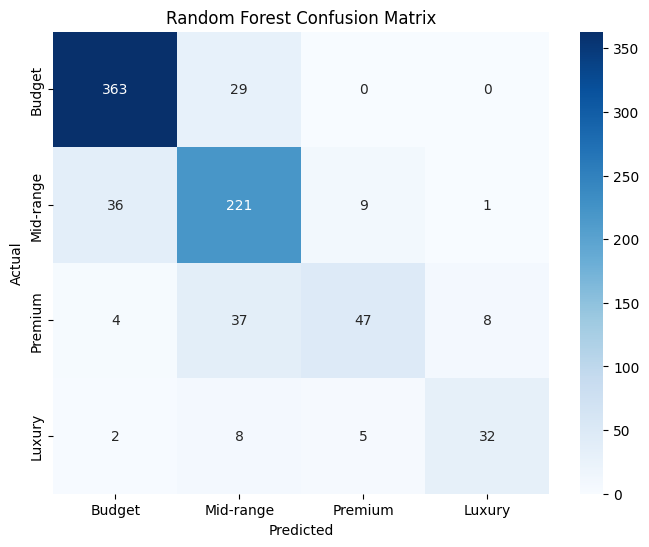

In [136]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Budget",
        "Mid-range",
        "Premium",
        "Luxury"
    ],
    yticklabels=[
        "Budget",
        "Mid-range",
        "Premium",
        "Luxury"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the Random Forest correctly classified most Budget and Mid-range vehicles.

The largest classification errors occurred between neighboring price categories.

For example:

- Some Budget vehicles were classified as Mid-range.
- Some Mid-range vehicles were classified as Budget.
- Premium vehicles were frequently confused with Mid-range vehicles.
- A smaller number of Premium and Luxury vehicles were confused with each other.

This is understandable because the price categories were created using fixed price thresholds. Vehicles close to these boundaries may have very similar characteristics despite belonging to different categories.

Overall, the model performs well across the major classes, but Premium remains the most difficult category to classify accurately.

## Handling Class Imbalance with Class Weights

The target classes are imbalanced, with fewer Premium and Luxury vehicles than Budget and Mid-range vehicles.

To address this, a new Random Forest model will be trained using `class_weight="balanced"`.

This automatically gives greater importance to minority classes during training.

The goal is to see whether recall and F1-score improve for Premium and Luxury vehicles without significantly reducing overall performance.

In [139]:
balanced_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [140]:
balanced_rf_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission',
                                                   'accident'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [141]:
balanced_rf_predictions = balanced_rf_model.predict(
    X_test
)

In [142]:
balanced_rf_accuracy = accuracy_score(
    y_test,
    balanced_rf_predictions
)

balanced_rf_precision = precision_score(
    y_test,
    balanced_rf_predictions,
    average="weighted",
    zero_division=0
)

balanced_rf_recall = recall_score(
    y_test,
    balanced_rf_predictions,
    average="weighted",
    zero_division=0
)

balanced_rf_f1 = f1_score(
    y_test,
    balanced_rf_predictions,
    average="weighted",
    zero_division=0
)

print("Balanced RF Accuracy:", balanced_rf_accuracy)
print("Balanced RF Precision:", balanced_rf_precision)
print("Balanced RF Recall:", balanced_rf_recall)
print("Balanced RF F1:", balanced_rf_f1)

Balanced RF Accuracy: 0.814214463840399
Balanced RF Precision: 0.8133674717865709
Balanced RF Recall: 0.814214463840399
Balanced RF F1: 0.8080605664439316


In [143]:
print(
    classification_report(
        y_test,
        balanced_rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Budget       0.90      0.92      0.91       392
      Luxury       0.79      0.70      0.74        47
   Mid-range       0.72      0.82      0.77       267
     Premium       0.74      0.44      0.55        96

    accuracy                           0.81       802
   macro avg       0.79      0.72      0.74       802
weighted avg       0.81      0.81      0.81       802



### Class Weight Experiment Result

A Random Forest model was trained using `class_weight="balanced"` to give more importance to minority classes.

The balanced model achieved approximately:

- **Accuracy:** 0.81
- **Weighted F1-score:** 0.81
- **Macro F1-score:** 0.74

Luxury recall improved slightly from approximately 0.68 to 0.70.

However, Premium recall decreased from approximately 0.49 to 0.44, and overall accuracy and F1-scores were slightly lower than the original Random Forest model.

Therefore, class weighting did not provide an overall improvement for this dataset, and the original Random Forest remains the better-performing classifier so far.

## Final Model Comparison

All classification models are compared using accuracy, weighted F1-score, and macro F1-score.

Because the dataset is imbalanced, macro F1-score is especially useful because it gives equal importance to all classes, including the smaller Premium and Luxury categories.

In [144]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],
    "Weighted F1": [
        dummy_f1,
        logistic_f1,
        tree_f1,
        rf_f1,
        balanced_rf_f1
    ]
})

model_comparison

,Model,Accuracy,Weighted F1
0,Dummy Classifier,0.488778,0.320940
1,Logistic Regression,0.801746,0.798017
2,Decision Tree,0.768080,0.767946
3,Random Forest,0.826683,0.821356
4,Balanced Random Forest,0.814214,0.808061


In [145]:
from sklearn.metrics import f1_score

dummy_macro_f1 = f1_score(
    y_test,
    dummy_predictions,
    average="macro",
    zero_division=0
)

logistic_macro_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro",
    zero_division=0
)

tree_macro_f1 = f1_score(
    y_test,
    tree_predictions,
    average="macro",
    zero_division=0
)

rf_macro_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro",
    zero_division=0
)

balanced_rf_macro_f1 = f1_score(
    y_test,
    balanced_rf_predictions,
    average="macro",
    zero_division=0
)

In [146]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],
    "Weighted F1": [
        dummy_f1,
        logistic_f1,
        tree_f1,
        rf_f1,
        balanced_rf_f1
    ],
    "Macro F1": [
        dummy_macro_f1,
        logistic_macro_f1,
        tree_macro_f1,
        rf_macro_f1,
        balanced_rf_macro_f1
    ]
})

model_comparison.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Accuracy,Weighted F1,Macro F1
3,Random Forest,0.826683,0.821356,0.755848
4,Balanced Random Forest,0.814214,0.808061,0.741198
1,Logistic Regression,0.801746,0.798017,0.714658
2,Decision Tree,0.768080,0.767946,0.699044
0,Dummy Classifier,0.488778,0.320940,0.164154


## Final Classification Model Selection

After comparing multiple classification models, the original Random Forest Classifier was selected as the final model.

It achieved the best overall balance of accuracy, weighted F1-score, and macro F1-score.

The model performed particularly well on Budget and Mid-range vehicles and also showed stronger performance on the Luxury class compared with earlier models.

Premium vehicles remained the most difficult class to classify, mainly because they had fewer training examples and often shared characteristics with neighboring Mid-range and Luxury categories.

An additional experiment using balanced class weights slightly improved Luxury recall but reduced overall model performance and Premium recall.

Therefore, the original Random Forest Classifier was retained as the final classification model.